# Trapping experiment June 2026

## Current on the extraction electrodes with Field emission tip on
Uses a Keithley multimeter to measure the current flow through the extraction electrodes 

In [7]:
import os
import pyvisa as visa
import time
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, \
                                                    plot_errbar, big_plt_font
big_plt_font()
from tqdm import trange, tqdm

rm = visa.ResourceManager()
instruments = rm.list_resources()
usb = list(filter(lambda x: 'USB' in x, instruments))

## Field emission tip voltage control
from edes.modules.power_supply import PSU_utils 
device_lib = PSU_utils.load_device_lib()
try:
    PSU = device_lib.PS350_viaDP832A('USB0::6833::3601::DP8B260200018::0::INSTR')
except Exception as e:
    print(f"Error connecting to PSU: {e}")

def ramp_down_tip(V0): 
    V = V0
    while V > 0: 
        PSU.set_voltage(max(V - 200, 0))
        V = V - 200 
    PSU.rigol.output_off(1)

def ramp_up_tip(Vf, V0): 
    PSU.rigol.output_on(1)
    V = V0
    while V < Vf: 
        PSU.set_voltage(max(V + 200, 0))
        V = V + 200 

## Valon control 
from qcodes_contrib_drivers.drivers.Valon.Valon_5015 import Valon5015
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
from edes.modules.trap_drive.utils import beep, V_to_P, P_to_V

rm = visa.ResourceManager()
# SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')
# print(SSA.query("*IDN?"))

addr = 'ASRL/dev/ttyUSB0::INSTR'
try: 
    valon = Valon5015(name="Valon", address=addr)
except Exception as e: 
    print(f"Error connecting to Valon at {addr}: {e}")
valon.frequency(1472114285)
valon.offset(0)
valon.power(0)
valon.modulation_db(0)
valon.modulation_frequency(1)
valon.low_power_mode_enabled(True)
valon.buffer_amplifiers_enabled(False)
status = valon.status()
print(status)

base_dir = '/home/electron/data/experiment_06042026'

## Spectrum analyzer control
SSA = rm.open_resource('TCPIP::192.168.169.161::INSTR')

Error connecting to PSU: [Errno 16] Resource busy
Error connecting to Valon at ASRL/dev/ttyUSB0::INSTR: 'Another instrument has the name: Valon'
-->amf 1
AMF 0.001 kHz
-->pdn 1
PDN 1;
-->oen 0
OEN 0;
-->stat
Valon Technology, 5019, 12202687, R5  version 1.2c   Build: Aug  8 2022  01:10:47
      VBAT = 1494   7.221 V
      UPTS = 1596    46.1 C
   PA TEMP = 1701    49.7 C
       +5V = 3055   4.922 V
       -5V = 1487  -5.128 V


Can use this function to basically read the voltage on Agilent, and current it to current based on the 200Mohm resistance. Note that 200MOhm cannot be directly measured on the meter, so you have to measure one at a time to be 100Mohm and infer. Meter is limited at 100MOhm, and will be ovld otherwise.

Here we use the Rigol power supply unit to control the high voltage power supply to turn on the tip. **Make sure to turn on the output of the power supply physically before running the code below**

To turn on, change ON to be 1

In [83]:
valon.frequency(1472114285)
valon.power(10)
ON = 1
valon.buffer_amplifiers_enabled(bool(ON))

Can scan the power, here it is scanning from 6dBm to 15dBm with step of 0.1dBm

Set frequency using this line

## Spectrum analyzer

In [84]:
freq_center = 198.016 # MHz
freq_span = 0 # MHz
RBW_AUTO = 0 #1-ON, 0-OFF
VBW_AUTO = 1 #1-ON, 0-OFF
SWT_AUTO = 1 #1-ON, 0-OFF
VBW_RBW_RAT = 1 
RBW = 1 #kHz
VBW = 1 #kHz
SWT = 10000 #ms
N_AVG = 32

# Configure frequency
SSA.write("SENS:FREQ:CENT " + str(freq_center) + " MHz")
SSA.write("SENS:FREQ:SPAN " + str(freq_span) + " MHz")

# Configure bandwidths and sweep time
SSA.write("SENS:BWID:AUTO " + str(RBW_AUTO))
SSA.write("SENS:BWID:VID:AUTO " + str(VBW_AUTO))
SSA.write("SENS:SWE:TIME:AUTO " + str(SWT_AUTO))
SSA.write("SENS:BWID:VID " + str(VBW) + " kHz")
SSA.write("SENS:BWID " + str(RBW) + " kHz")
SSA.write("SENS:BWID:VID:RAT " + str(VBW_RBW_RAT))
SSA.write("SENS:SWE:TIME " + str(SWT) + " ms")
SSA.write(f':AVERage:TRACe1:COUNt {N_AVG}')
SSA.write(':AVERage:TRACe1:STATe ON')

# Set sweep mode to FFT
SSA.write(":SWEep:MODE FFT")

17

In [11]:
def take_vna_sweep(filename, folder_path, N_AVG=32): 
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path,filename)
    SSA.write(":AVERage:TRAC1:CLEar")
    while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
        continue
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    # Number of points in the trace
    num_points = len(data_arr_C)
    
    # Generate frequency axis in MHz
    freq_start = freq_center - freq_span / 2
    freq_stop  = freq_center + freq_span / 2
    freq_axis = np.linspace(freq_start, freq_stop, num_points)
    np.savez(file_path, freq=freq_axis, data=data_arr_C)
    return data_arr_C, freq_axis

In [13]:
filename = '198MHz-0604.csv'
folder_path = base_dir
data, freq = take_vna_sweep(filename, folder_path)

In [59]:
all_P = np.arange(6,13,0.005)
t0 = time.time()
for p in all_P: 
    valon.power(p)
time.time()-t0

36.53804421424866

In [14]:
PSU.set_voltage(1000)

In [40]:
valon.buffer_amplifiers_enabled(bool(1))

In [45]:
valon.power(10)

In [87]:
# 1. Define system impedance (typically 50 Ohms)
# can choose anything here, just a code to make the voltage be equal distance
R = 50 

# 2. Voltage boundaries matching 6 dBm and 15 dBm
v_min = 0.4
v_max = 1.0

# 3. Create a linear scan of voltage (equal distances)
# 1800 steps matches the resolution of your original array
voltage_scan = np.linspace(v_min, v_max, 800)

# 4. Convert the linear voltage steps back to the required dBm inputs
p_watts = (voltage_scan ** 2) / R
dbm_scan = 10 * np.log10(p_watts / 0.001)
dbm_scan[0], dbm_scan[-1]

(np.float64(5.051499783199061), np.float64(13.010299956639813))

In [ ]:
T_idle = 1
T_load = 2 
T_wait = 30 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 2000
V_off = 600

N_rep = 5 

PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
# valon.power(11)
valon.buffer_amplifiers_enabled(bool(1))

# 1. Define system impedance (typically 50 Ohms)
# can choose anything here, just a code to make the voltage be equal distance
R = 50 

# 2. Voltage boundaries matching 6 dBm and 13 dBm
v_min = 0.1
v_max = 1.0

# 3. Create a linear scan of voltage (equal distances)
# 1800 steps matches the resolution of your original array
voltage_scan = np.linspace(v_min, v_max, 800)

# 4. Convert the linear voltage steps back to the required dBm inputs
p_watts = (voltage_scan ** 2) / R
dbm_scan = 10 * np.log10(p_watts / 0.001)

# all_P = np.arange(6,15,0.005)
all_P = dbm_scan

PSU.set_voltage(V_on)
# /valon.buffer_amplifiers_enabled(bool(1))
for i in tqdm(range(N_rep)):
    valon.power(all_P[0])
    sleep(8)
    SSA.write(":AVERage:TRAC1:CLEar")
    SSA.query(":TRACe1:DATA?")
    for p in all_P: 
        valon.power(p)
    sleep(8)
    # valon.buffer_amplifiers_enabled(bool(0))
    # sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
valon.power(all_P[0])
PSU.set_voltage(V_off)

100%|█████████████████████████████████████████████| 5/5 [03:04<00:00, 36.98s/it]


/tmp/ipykernel_340826/2805022243.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


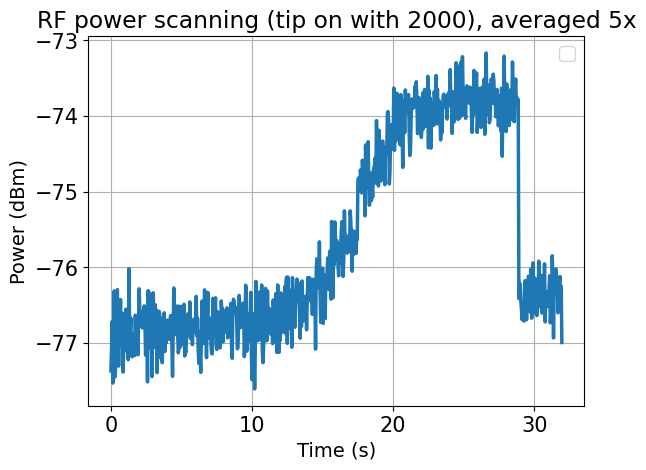

In [101]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF power scanning (tip on with {V_on}), averaged {N_rep}x')
# plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
# plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(V_off)
beep()

In [103]:
T_idle = 1
T_load = 2 
T_wait = 30 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 600
V_off = 600

N_rep = 5 

PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
# valon.power(11)
valon.buffer_amplifiers_enabled(bool(1))

# 1. Define system impedance (typically 50 Ohms)
# can choose anything here, just a code to make the voltage be equal distance
R = 50 

# 2. Voltage boundaries matching 6 dBm and 13 dBm
v_min = 0.1
v_max = 1.0

# 3. Create a linear scan of voltage (equal distances)
# 1800 steps matches the resolution of your original array
voltage_scan = np.linspace(v_min, v_max, 800)

# 4. Convert the linear voltage steps back to the required dBm inputs
p_watts = (voltage_scan ** 2) / R
dbm_scan = 10 * np.log10(p_watts / 0.001)

# all_P = np.arange(6,15,0.005)
all_P = dbm_scan

PSU.set_voltage(V_on)
# /valon.buffer_amplifiers_enabled(bool(1))
for i in tqdm(range(N_rep)):
    valon.power(all_P[0])
    sleep(8)
    SSA.write(":AVERage:TRAC1:CLEar")
    SSA.query(":TRACe1:DATA?")
    for p in all_P: 
        valon.power(p)
    sleep(8)
    # valon.buffer_amplifiers_enabled(bool(0))
    # sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
valon.power(all_P[0])
PSU.set_voltage(V_off)

100%|█████████████████████████████████████████████| 5/5 [03:04<00:00, 36.98s/it]


/tmp/ipykernel_340826/4164545238.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


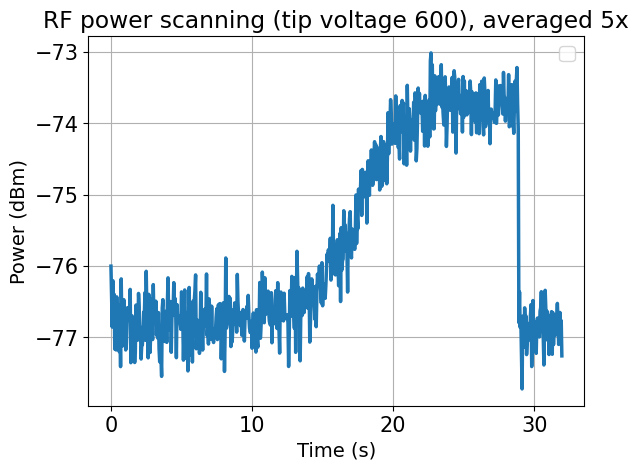

In [104]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF power scanning (tip voltage {V_on}), averaged {N_rep}x')
# plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
# plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(V_off)
beep()

In [111]:
T_idle = 1
T_load = 2 
T_wait = 24 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 1500
V_off = 600

N_rep = 5 

PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
# valon.power(11)
valon.buffer_amplifiers_enabled(bool(1))

# 1. Define system impedance (typically 50 Ohms)
# can choose anything here, just a code to make the voltage be equal distance
R = 50 

# 2. Voltage boundaries matching 6 dBm and 13 dBm
v_min = 0.1
v_max = 1.0

# 3. Create a linear scan of voltage (equal distances)
# 1800 steps matches the resolution of your original array
voltage_scan = np.linspace(v_min, v_max, 800)

# 4. Convert the linear voltage steps back to the required dBm inputs
p_watts = (voltage_scan ** 2) / R
dbm_scan = 10 * np.log10(p_watts / 0.001)

# all_P = np.arange(6,15,0.005)
all_P = dbm_scan

PSU.set_voltage(V_on)
# /valon.buffer_amplifiers_enabled(bool(1))
for i in tqdm(range(N_rep)):
    valon.power(all_P[0])
    sleep(8)
    SSA.write(":AVERage:TRAC1:CLEar")
    SSA.query(":TRACe1:DATA?")
    for p in all_P: 
        valon.power(p)
    sleep(8)
    # valon.buffer_amplifiers_enabled(bool(0))
    # sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)
valon.power(all_P[0])
PSU.set_voltage(V_off)

100%|█████████████████████████████████████████████| 5/5 [03:04<00:00, 36.98s/it]


/tmp/ipykernel_340826/4164545238.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


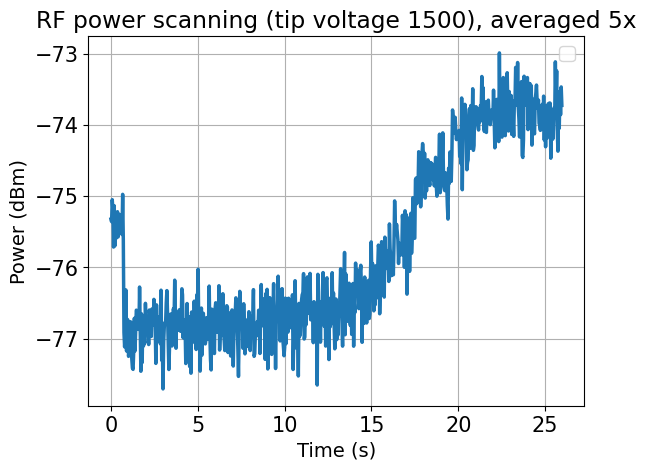

In [112]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF power scanning (tip voltage {V_on}), averaged {N_rep}x')
# plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
# plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(V_off)
beep()

In [23]:
T_idle = 1
T_load = 2 
T_wait = 30 
T_RF_buffer = 1
T_SSA_buffer = 0.1
V_on = 2000
V_off = 600

N_rep = 1 

PSU.set_voltage(V_off)
T_total = T_idle + T_load + T_wait + T_SSA_buffer + T_RF_buffer
T_exp = T_load + T_wait + T_idle + T_RF_buffer
t_load_start = T_idle
t_load_end = t_load_start + T_load
t_RF_on = 0 
t_RF_off = t_load_end + T_wait
SSA.write(f"SENS:SWE:TIME {T_total} s")


all_data = []
valon.power(10)
valon.buffer_amplifiers_enabled(bool(1))

freqs = np.arange(1.42e9, 1.52e9, 1e5)

# /valon.buffer_amplifiers_enabled(bool(1))
for i in tqdm(range(N_rep)):
    SSA.write(":AVERage:TRAC1:CLEar")
    sleep(T_idle)
    # PSU.set_voltage(V_on)
    sleep(T_load)
    # for p in all_P: 
    #     valon.power(p)
    # PSU.set_voltage(V_off)
    for f in freqs:
        valon.frequency(f)
    # sleep(T_wait)
    # valon.buffer_amplifiers_enabled(bool(0))
    # sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)

100%|█████████████████████████████████████████████| 1/1 [00:34<00:00, 34.23s/it]


/tmp/ipykernel_340826/2975893419.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


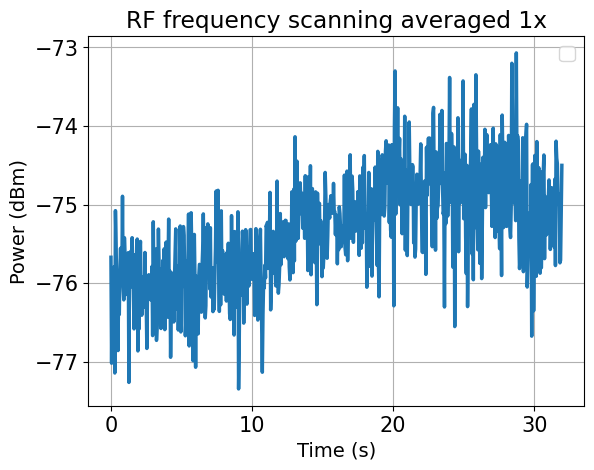

In [24]:
num_points = len(all_data[0])
t_axis = np.linspace(0, T_total, num_points) 
idx = np.where(t_axis < T_exp-2)
plot(t_axis[idx], np.mean(all_data, axis=0)[idx], xlabel='Time (s)', 
     ylabel='Power (dBm)', title=f'RF frequency scanning averaged {N_rep}x')
# plt.axvline(t_load_start, linestyle='--', color='r', label='load start') 
# plt.axvline(t_load_end, linestyle='--', color='k', label='load end')
# plt.axvline(t_RF_on, linestyle='--', color='g', label='RF on') 
# plt.axvline(t_RF_off, linestyle='--', color='purple', label='RF off')
plt.legend()
plt.show()
PSU.set_voltage(V_off)
beep()

In [33]:
valon.power(10)
valon.buffer_amplifiers_enabled(bool(1))
freqs = np.arange(1.45e9, 1.48e9, 0.05e5)
for f in freqs:
        valon.frequency(f)

In [ ]:
valon.buffer_amplifiers_enabled(bool(0))

In [72]:
def take_vna_sweep(filename, folder_path, N_AVG=32): 
    os.makedirs(folder_path, exist_ok=True)
    file_path = os.path.join(folder_path,filename)
    SSA.write(":AVERage:TRAC1:CLEar")
    while int(SSA.query(":AVERage:TRACe1?")) < N_AVG: 
        continue
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    # Number of points in the trace
    num_points = len(data_arr_C)
    
    # Generate frequency axis in MHz
    freq_start = freq_center - freq_span / 2
    freq_stop  = freq_center + freq_span / 2
    freq_axis = np.linspace(freq_start, freq_stop, num_points)
    np.savez(file_path, freq=freq_axis, data=data_arr_C)
    return data_arr_C, freq_axis

In [82]:
valon.power(10)
valon.frequency(1472114285)
valon.buffer_amplifiers_enabled(bool(1))

In [ ]:
valon.power(10)
valon.buffer_amplifiers_enabled(bool(1))
all_data = []
freqs = [1372114285, 1472114285]
for freq in freqs:
    valon.frequency(freq)
    sleep(1)
    take_vna_sweep(f'{freq}Hz-0604.csv', base_dir, N_AVG=32)


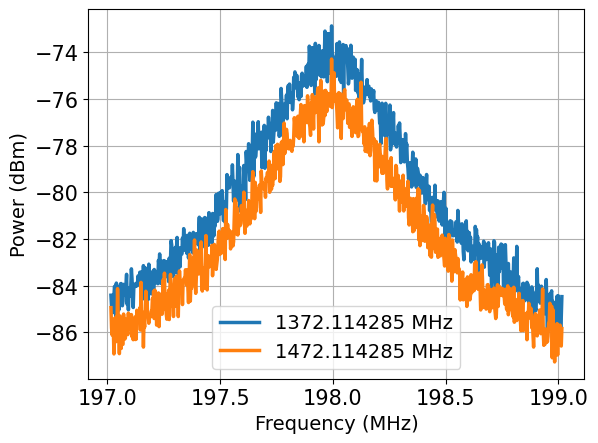

In [75]:

all_plots = [f'{freq}Hz-0604.csv' for freq in freqs]
labels = [f'{freq/1e6} MHz' for freq in freqs]

for i in range(len(all_plots)):
    plots = all_plots[i] 
    label = labels[i]
    data = np.load(f'{base_dir}/{plots}.npz') 
    plot(data['freq'], data['data'], alpha=1, xlabel='Frequency (MHz)',
         ylabel='Power (dBm)', label=label)


In [53]:
from ipywidgets import interact, FloatSlider

# --- Your Existing Valon Setup ---
valon.power(10)
valon.buffer_amplifiers_enabled(True)

# --- Controller Function ---
def change_valon_freq(freq_Mhz):
    freq_hz = freq_Mhz * 1e6
    valon.frequency(freq_hz)
    print(f"Target set to: {freq_Mhz:.2f} MHz")

# --- Interactive Slider ---
interact(
    change_valon_freq, 
    freq_Mhz=FloatSlider(
        value=1445, 
        min=1000.0, 
        max=4000.0, 
        step=1.0, 
        description='Freq (MHz):',
        continuous_update=True # Set to False if the serial connection lags
    )
)

interactive(children=(FloatSlider(value=1445.0, description='Freq (MHz):', max=4000.0, min=1000.0, step=1.0), …

<function __main__.change_valon_freq(freq_Mhz)>

In [ ]:
for i in tqdm(range(N_rep)):
    SSA.write(":AVERage:TRAC1:CLEar")
    sleep(T_idle)
    # PSU.set_voltage(V_on)
    sleep(T_load)
    # for p in all_P: 
    #     valon.power(p)
    # PSU.set_voltage(V_off)
    for f in freqs:
        valon.frequency(f)
    # sleep(T_wait)
    # valon.buffer_amplifiers_enabled(bool(0))
    # sleep(T_RF_buffer)
    data_str_C = SSA.query(":TRACe1:DATA?")
    data_arr_C = np.array([float(val) for val in data_str_C.split(',')]) 
    all_data.append(data_arr_C)

In [113]:
ramp_down_tip(V_off)